In [70]:
suppressPackageStartupMessages({
    library(dplyr)
    library(magrittr)
    library(readr)
    library(ggplot2)
    library(tictoc)
    library(ggrastr)
    library(RColorBrewer)
    library(cowplot)
    library(reshape2)
    library(data.table)
    library(sccore)
    library(NMF)
    library(ggplot2)
    library(CRF)
    library(ggrepel)
    library(arrow)
    library(parallel)
    library(igraph)
    library(gtools)
    library(RColorBrewer)
    library(Matrix)
    library(readr)
    library(Seurat)
    library(sparseMatrixStats)
    library(cowplot)
    library(devtools)
    library(RANN)
    library(grid)
})

suppressMessages({
    devtools::load_all('./cellAdmix')
    devtools::load_all('./cellAdmix-Notebooks')
    load_arial_font()
})

Two data files are needed for this tutorial, which can be downloaded at the following url:
https://nanostring.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/nsclc-ffpe-dataset/ 
-"Processed Giotto Object"
-"Lung 5-1 Data files"

Once downloaded, you can preprocess these files using the functions below from /cellAdmix-Notebooks/R/data_loading.R

Alternatively, see the tutorial called NSCLC_tutorial_sample_data.ipynb to run the pipeline on a much smaller subset of the data. However, that tutorial does not include the differential expression and exploration analyses.

In [35]:
# load the molecule-level NSCLC spatial data
# these functions are from cellAdmix-Notebooks/data_loading.R
cell_meta <- prepare_nsclc_metadata(reps='one')
df <- prepare_nsclc_transcript_data(cell_meta,reps='one')

Important: to run the pipeline of KNN graph -> NMF -> CRF, we need to include columns
in the molecule-level dataframe called:
- 'cell' specifying the cell that the molecule belongs to
- 'celltype' specifying the type of the cell
- 'x','y','z' specifying the coordinates of the transcript. Note, if no z coordinates exist for your data, you can set that column to a constant value.
- 'gene' specifying the gene that the molecule corresponds to
- 'mol_id' a character which is unique to a give molecule (can just be row index)

In [36]:
# add annotation for regions we'll compare. It will be needed later for DE
cell_meta$regions_compare <- sapply(cell_meta$niche, switch, "tumor interior"="tumor", "stroma"="stroma", NA)

## Exploration plots

Let's look at the distribution of cell types and annotated regions over the tissue section

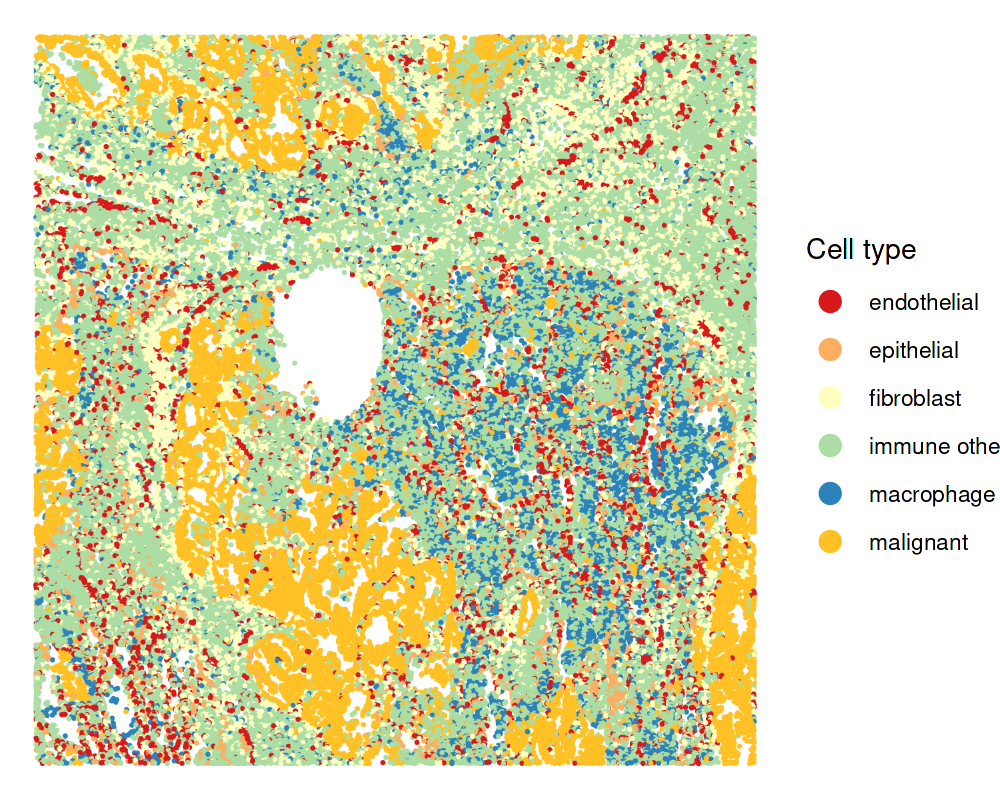

In [37]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# first show cells colored by cell type
ggplot(cell_meta,aes(x=x,y=y,color=celltype_coarse)) +
  geom_point_rast(size=.001) +
  scale_colour_manual(values = c(brewer.pal(5, 'Spectral'), 'goldenrod1')) +
  guides(colour = guide_legend(override.aes = list(size=3))) +
  labs(color='Cell type') +
  theme_void() +
  theme(legend.text=element_text(size=8),
        legend.title=element_text(size=10))

Next, show cells colored by region assignment

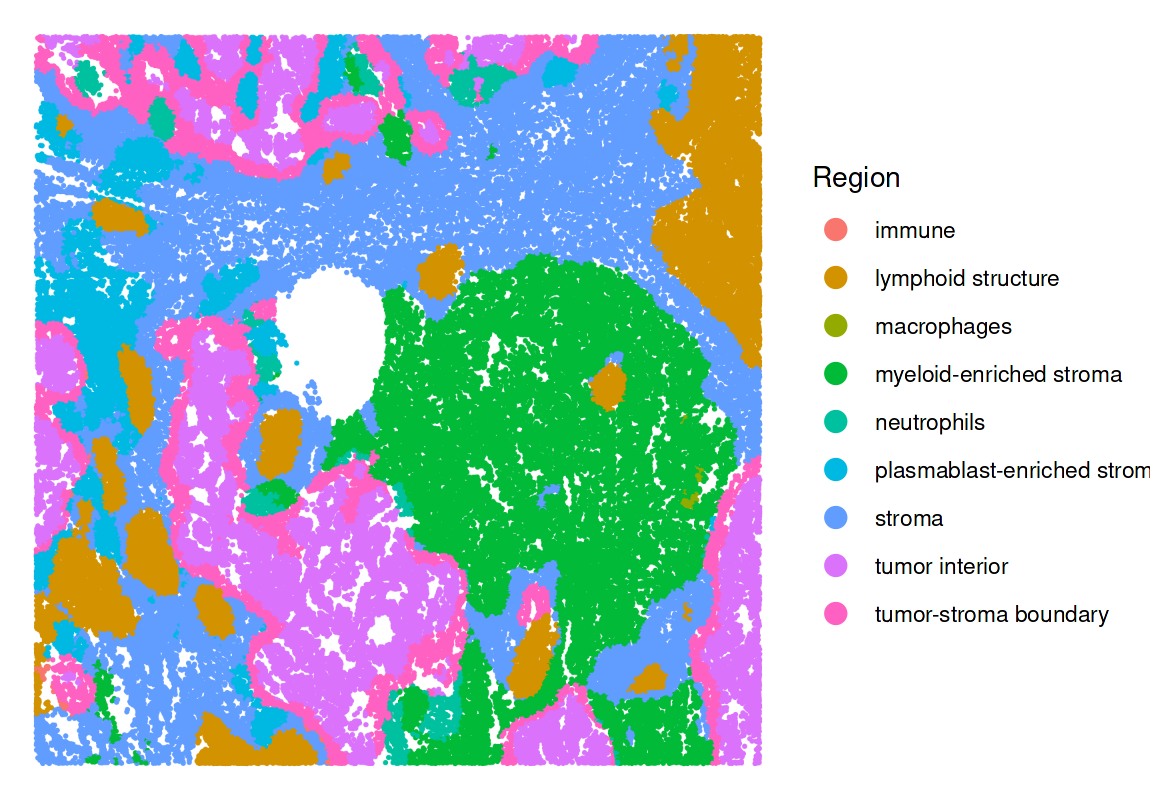

In [38]:
options(repr.plot.width = 5.75, repr.plot.height = 4, repr.plot.res = 200)

ggplot(cell_meta,aes(x=x,y=y,color=niche)) +
  geom_point_rast(size=.001) +
  guides(colour = guide_legend(override.aes = list(size=3))) +
  labs(color='Region') +
  theme_void() +
  theme(legend.text=element_text(size=8),
        legend.title=element_text(size=10))

## Malignant markers in fibroblasts

Next, we'll illustrate how fibroblasts in the tumor interior region appear to overexpress malignant cell markers relative to fibroblasts in the stroma. This effect will be apparent when running differential expression between fibroblasts in the tumor interior versus the stroma regions, as malignant markers will appear to be upregulated for fibroblasts in the tumor interior.

In [39]:
# convert molecule-level data to gene x cell counts matrix as seurat object
so_orig <- get_counts_meta_seurat(df)

In [40]:
# reduce data to just the fibroblast cells in the tested regions
meta_orig <- so_orig@meta.data
dat_orig <- so_orig@assays$RNA@counts

cells_keep <- cell_meta %>% filter(celltype=='fibroblast', !is.na(regions_compare)) %>% .$cell
meta_orig <- cell_meta[cells_keep,]
dat_orig <- dat_orig[,cells_keep]

print(dim(dat_orig))
print(dat_orig[1:5,1:5])

[1]  960 7031
5 x 5 sparse Matrix of class "dgCMatrix"
     c_1_1_18 c_1_1_25 c_1_1_26 c_1_1_36 c_1_1_58
AATK        .        .        .        .        .
ABL1        .        .        .        .        .
ABL2        .        .        .        .        .
ACE         .        .        .        .        .
ACE2        .        .        .        .        .


In [41]:
## run de for fibroblasts between tumor and stroma
regions_compare <- meta_orig %>% {setNames(.$regions_compare, rownames(.))}
de_out_orig <- run_pagoda_de(dat_orig, groups=regions_compare)$tumor

Warning message:
“Removed 956 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


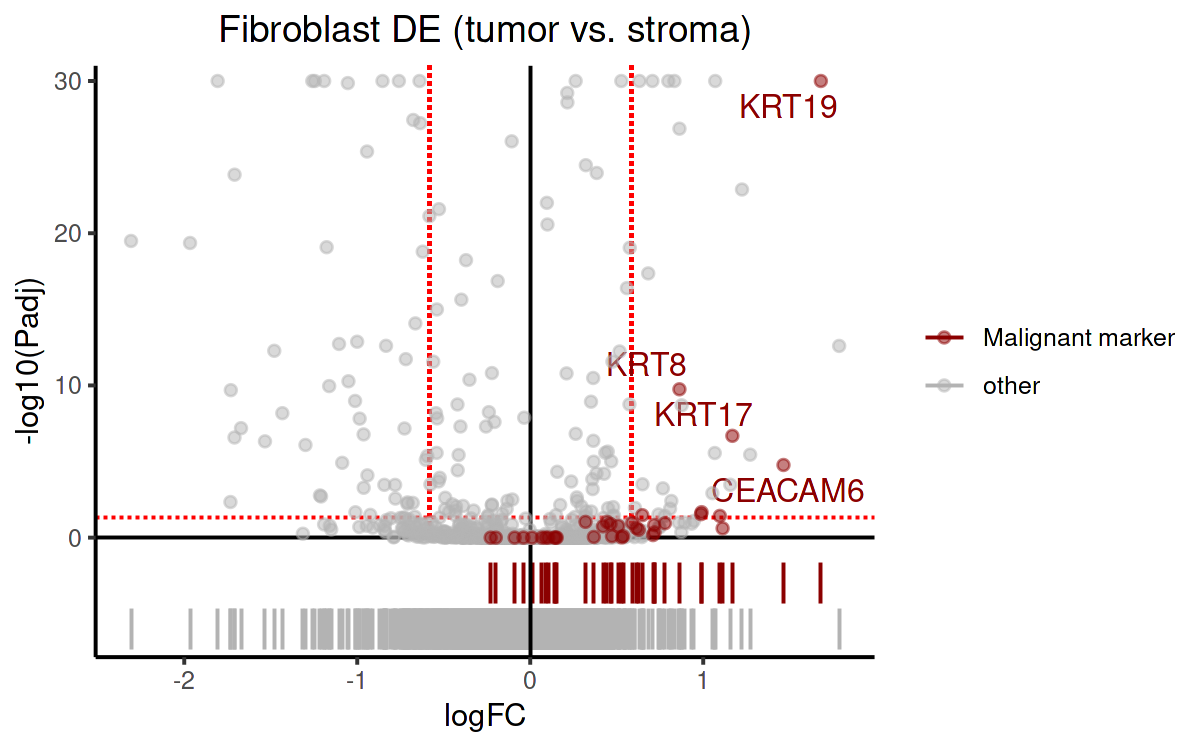

In [43]:
options(repr.plot.width = 6, repr.plot.height = 3.75, repr.plot.res = 200)

tumor_marker_genes <- c(
    "KRT19", "KRT8", "KRT18", "TACSTD2", "CEACAM6", "CDH1", "EPCAM",
    "CLDN4", "SFN", "PHLDA2", "DDR1", "AGR2", "KRT6A", "KRT17",
    "CD24", "KRT5", "AQP3", "SLC2A1", "KRT7", "COL17A1", "FASN",
    "KRT15", "ITGA2", "ERBB3", "S100A2", "SPINK1", "ITGB4", "PIGR",
    "SOX2", "ITGA3", "CYSTM1", "NTRK2", "MAPK13", "CCND1", "HDAC1", "EGFR"
)

genes_to_label <- c('KRT19','KRT8','KRT17','CEACAM6')

de_volcano_plot(de.df=de_out_orig, tumor.marker.genes=tumor_marker_genes, genes.to.label=genes_to_label) +
    ggtitle('Fibroblast DE (tumor vs. stroma)')

In the above plot we can see that malignant marker genes rise to the top of the DE genes in fibroblast cells. Specifically, they appear upregulated for fibroblasts in the tumor relative to stroma regions. The malignant marker genes were identified in a separate scRNA-seq dataset.

## Removing admixture

Next, we'll apply our correction method to identify and remove admixture genes from the fibroblast cells.

In [46]:
## first downsampling cells to reduce runtime
df_sub <- samp_ct_equal(df,cell_meta,num.cells.samp=2000)

In [47]:
## now make NCV matrix and run NMF decomposition

# k is the number of factors to extract
# h is the knn neighborhood size
# nmol_dsamp determines how many molecules we want to further downsample to before running NMF (for runtime purposes)
num_factors <- 10
res <- run_knn_nmf(df_sub,k=num_factors,h=20,nmol.dsamp=10000,n.cores=30)

NMF algorithm: 'ls-nmf'

Multiple runs: 30

Mode: parallel (30/96 core(s))



Runs: |==================================================| 100%
System time:
      user     system    elapsed 
 70698.973 305251.034   4099.027 


Now, we'll compute the neighborhood composition vectors (knn for each molecule) and run NMF on this

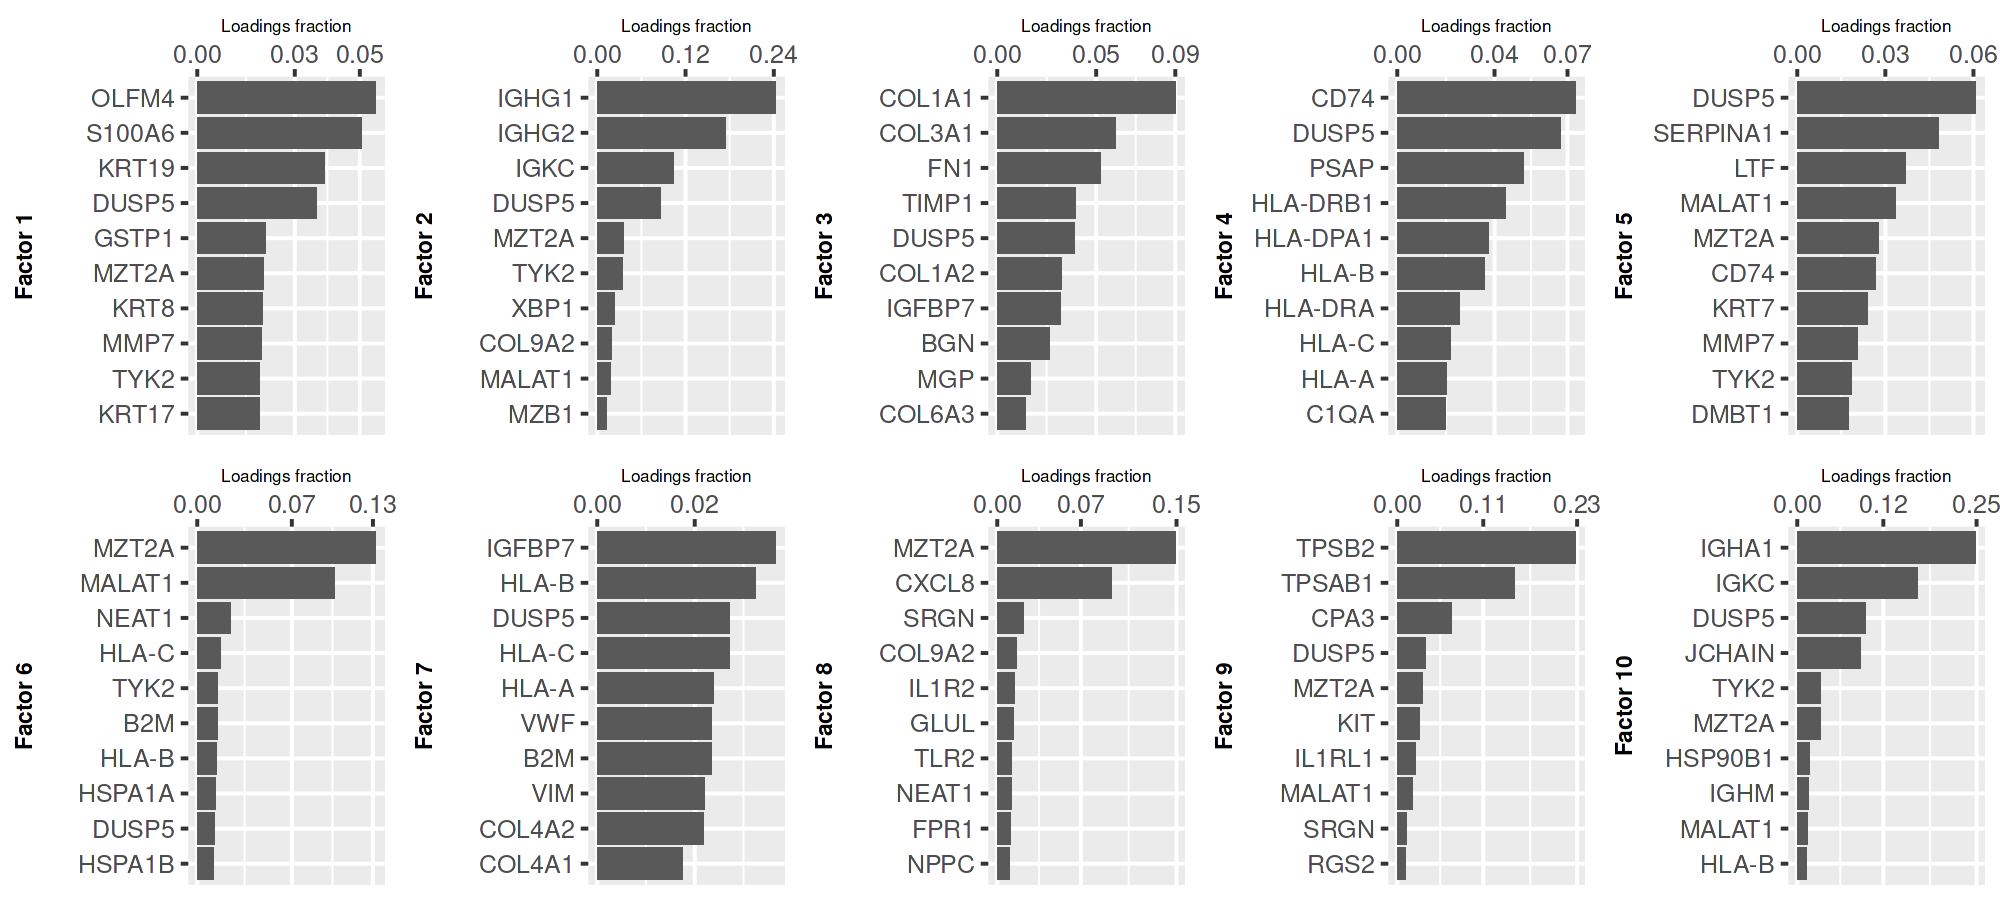

In [50]:
# Plot some top loading genes for each factor
options(repr.plot.width = 10, repr.plot.height = 4.5, repr.plot.res = 200)
plot_nmf_loadings(res, nplt.row=2)

Here, factor 1 appears to represent admixture from malignant cells since several of the top loading genes are KRT19, KRT8, and KRT17, which are specific malignant markers. Note that the dataset downsampling step may cause these results to look slightly different from yours, so you will need to identify which factor corresponds to the malignant cell admixture and modify the following cell.

In [51]:
## now run CRF to assign molecules to factors
# note: you need to use the full df here, not the subset one used for nmf above

# num.nn is the knn k value for the CRF
# same.label.ratio is the ratio of transition probabilities for (no transition)/(transition to factor x)
# normalize.by is the method for normalizing NMF loadings ('gene' normalizes each gene by the loadings sum for a factor)
crf_res <- run_crf_all(df,res,num.nn=10,same.label.ratio=5,
                           normalize.by='gene',n.cores=30)

Next, we will run automated factor annotation with our cell-bridging method in order to label factors as "foreign" or "native" to each cell type for removal

In [52]:
# get knn result for all molecules over the whole data to get adjacent cells later
knn_res <- get_mol_knn(df,knn_k=10)
ncm_ct <- knn_res[[1]]
ncm_cell <- knn_res[[2]]

# knn.k here is a knn parameter used in identifying the molecules in the target cell that are connected to the source cell
bridge_raw <- run_bridge_test(df,crf_res,cell_meta,ncm_ct,ncm_cell,ncells.samp=200,
                                  knn.k=20,n.cores=20)

In [55]:
## parsing bridge results

# nmf.type should be 'joint' if nmf was run on all cell types together
# p.thresh is the pval threshold for selecting factors for removal (usually better to be lax)
all_ctypes <- unique(cell_meta$celltype)
bridge_res <- extract_bridge_res(bridge_raw,all.ctypes=all_ctypes,
                                 n.factors=num_factors,nmf.type='joint',p.thresh=.1,adj.pvals=FALSE)

In [72]:
## run a check to make sure we do not remove any native factors

# the knn_k parameter here is used to isolate cells not within this distance to a source admix cell type
# median_thresh specifies an expression threshold to prevent factor removal if distant cells express the factor above it
fp_checks <- check_fp(df, cell_meta, crf_res, bridge_res, do_clean=TRUE, knn_k=100, median_thresh=.1)


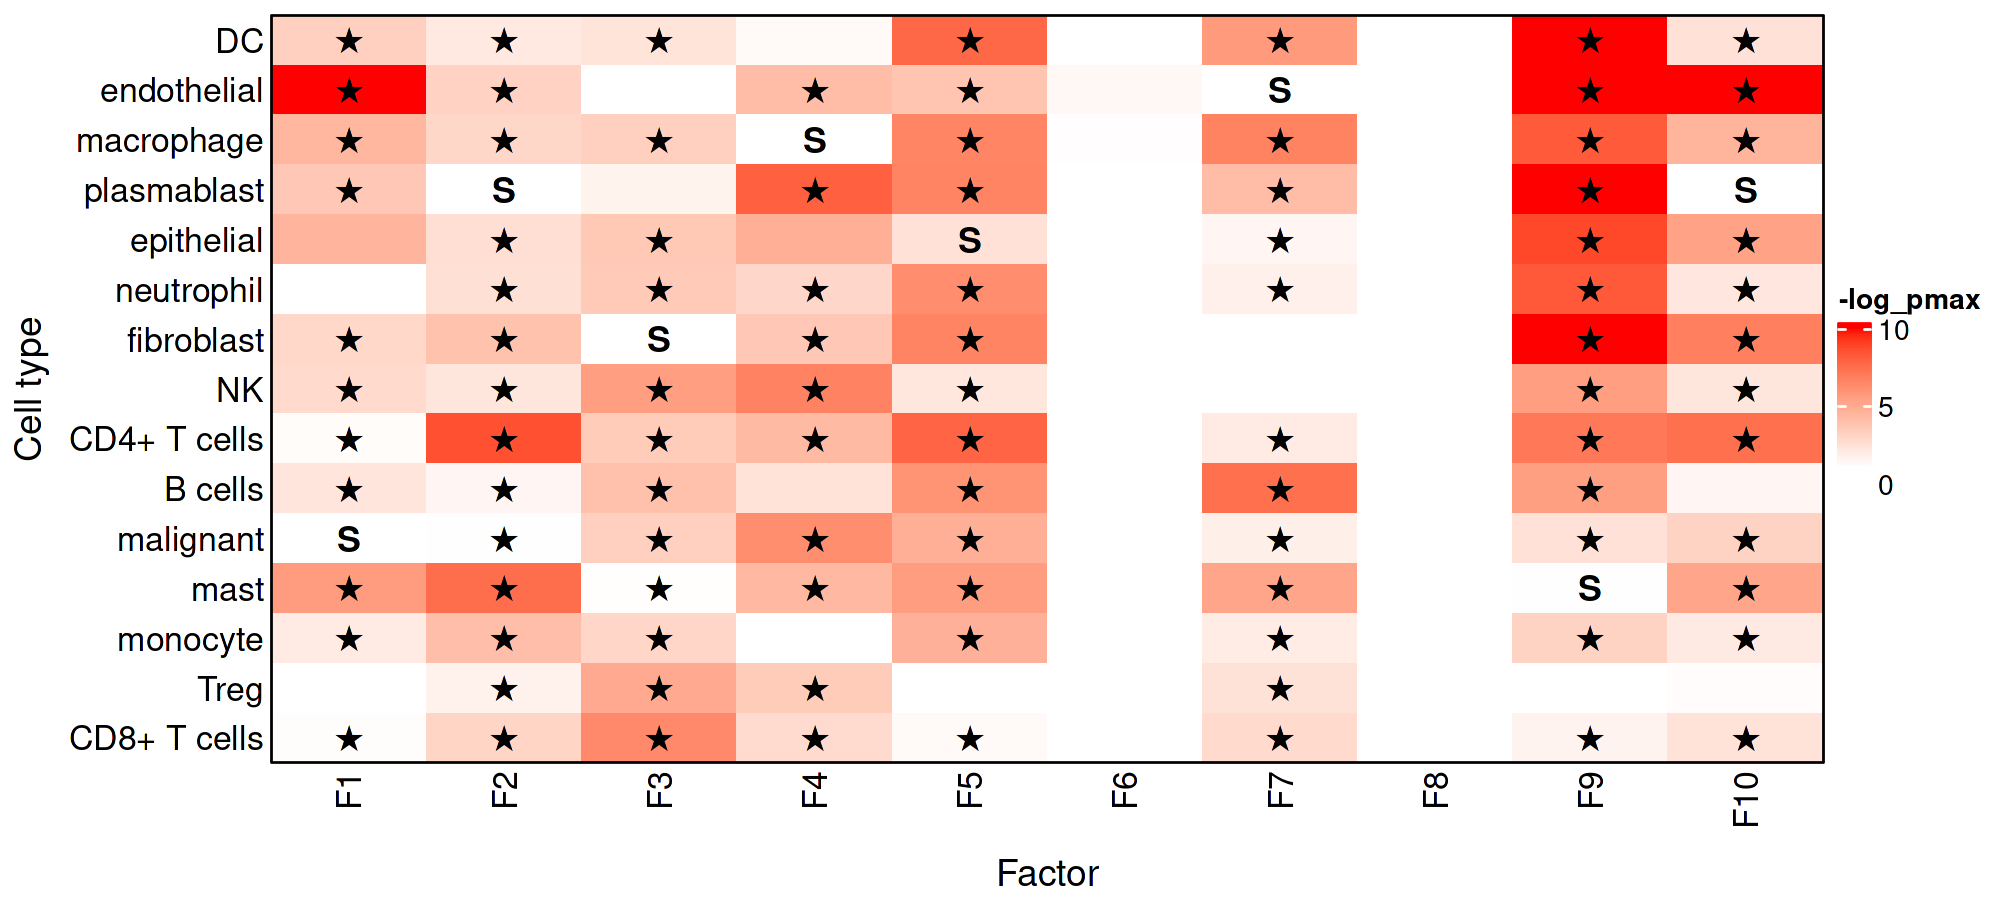

In [76]:
## plot the annotation result
bridge_pv_mat <- extract_bridge_res(
  bridge_raw, all_ctypes, num_factors, nmf.type='joint', p.thresh=.1,
  adj.pvals=FALSE, get.p.mat=TRUE
)
bridge_rs <- cellAdmix:::collapse_row_col(bridge_pv_mat, c.type='r_max')
bridge_sources <- bridge_res[[2]]
hm1 <- plot_annot_hmap(bridge_rs,bridge_sources,fp_checks,annot.type='bridge')
print(hm1)

The factors identified as foreign in the cell type at the corresponding row have stars. The identified source cell types for each factor are labelled with an S. Now, we will remove the factors labelled as foreign to each cell type.

In [77]:
df$factor <- crf_res[,1]
df_cln <- df[!(paste(df$factor, df$celltype, sep = "_") %in% fp_checks), ]

print(paste0('Number of molecules originally: ', nrow(df)))
print(paste0('Number of molecules after cleaning: ', nrow(df_cln)))

[1] "Number of molecules originally: 30245074"
[1] "Number of molecules after cleaning: 26994500"


Next, we will demonstrate how the cleaning procedure corrected the DE artifacts in fibroblast cells

In [78]:
df_fib_cln <- df_cln[df_cln$celltype=='fibroblast',]

In [79]:
# compute a clean counts matrix from molecule level data
so_cln <- get_counts_meta_seurat(df_fib_cln)
meta_cln <- so_cln@meta.data
dat_cln <- so_cln@assays$RNA@counts

cells_both <- intersect(colnames(dat_orig),colnames(dat_cln))
dat_orig <- dat_orig[,cells_both]
dat_cln <- dat_cln[,cells_both]

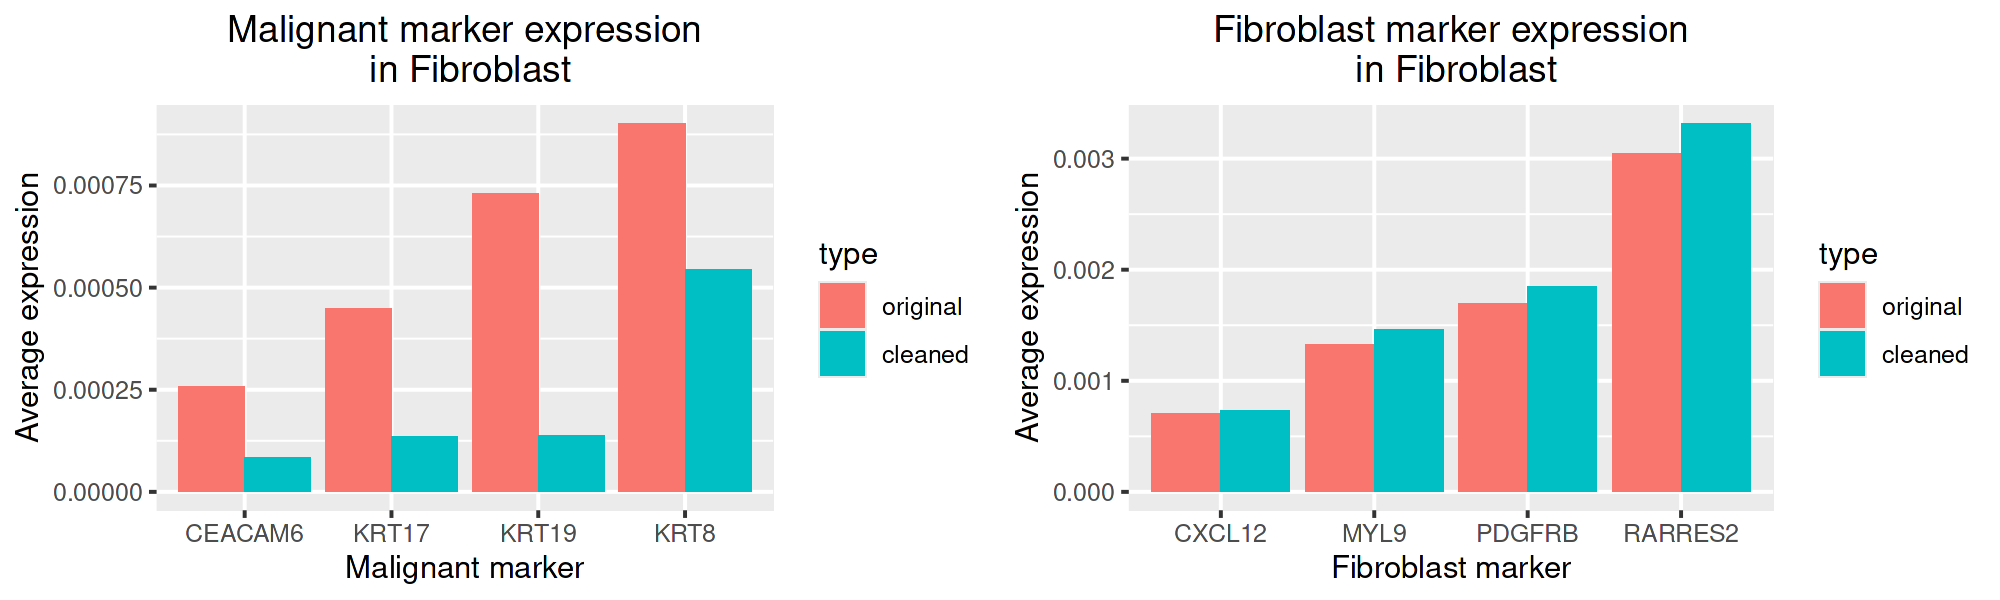

In [82]:
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 200)

plot_expression_comparison(
    as.matrix(dat_orig), as.matrix(dat_cln), 
    markers.native=c('MYL9','CXCL12','PDGFRB','RARRES2'), 
    markers.admix=c('KRT19','KRT8','KRT17','CEACAM6'), 
    admixture.type='Malignant', native.type='Fibroblast'
)

Now, we show how this cleaning process mitigates the degree to which admixture dominates the DE results.

In [83]:
de_out_cln <- run_pagoda_de(dat_cln, groups=regions_compare)$tumor

Warning message:
“Removed 956 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


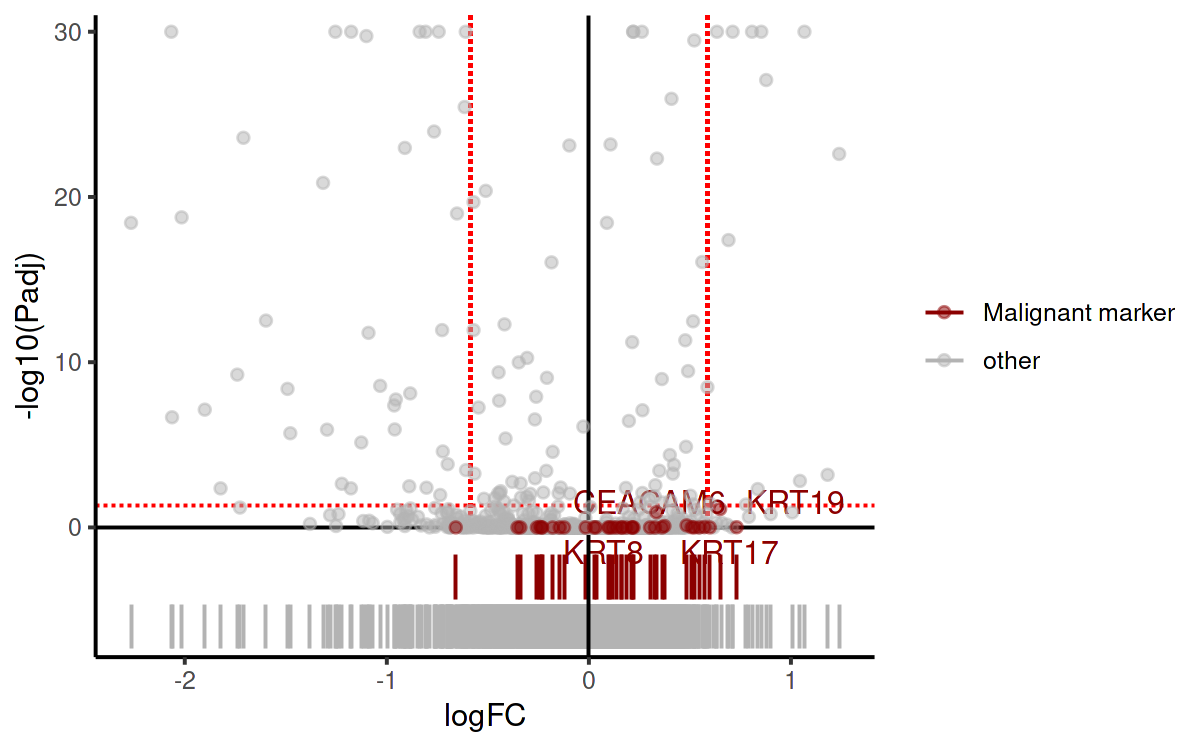

In [85]:
options(repr.plot.width = 6, repr.plot.height = 3.75, repr.plot.res = 200)
de_volcano_plot(de_out_cln, tumor_marker_genes, genes.to.label=genes_to_label)

Warning message:
“Removed 956 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


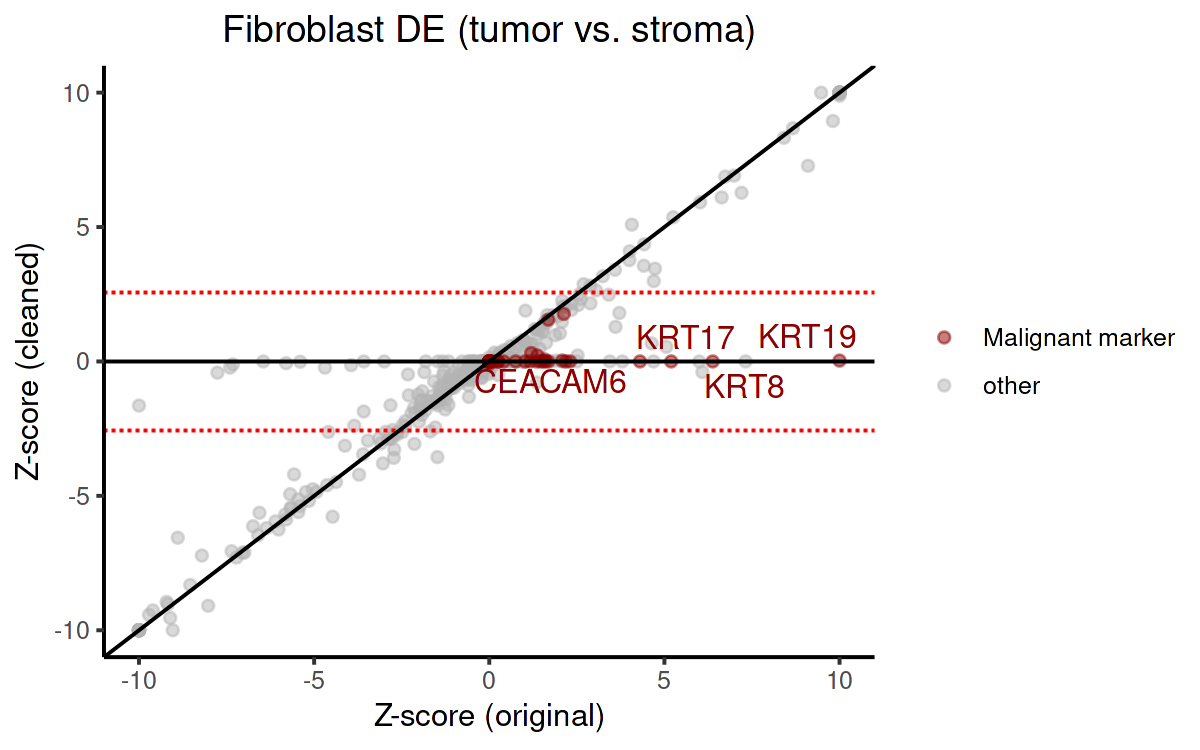

In [87]:
plot_de_comparison(
    de_out_orig, de_out_cln,
    genes.to.label=genes_to_label,
    tumor.marker.genes=tumor_marker_genes
) + ggtitle('Fibroblast DE (tumor vs. stroma)')

We see that the fibroblast DE Z-scores for malignant cell markers are no longer significant after applying the cleaning procedure.